In [31]:
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  4 of 4 completed


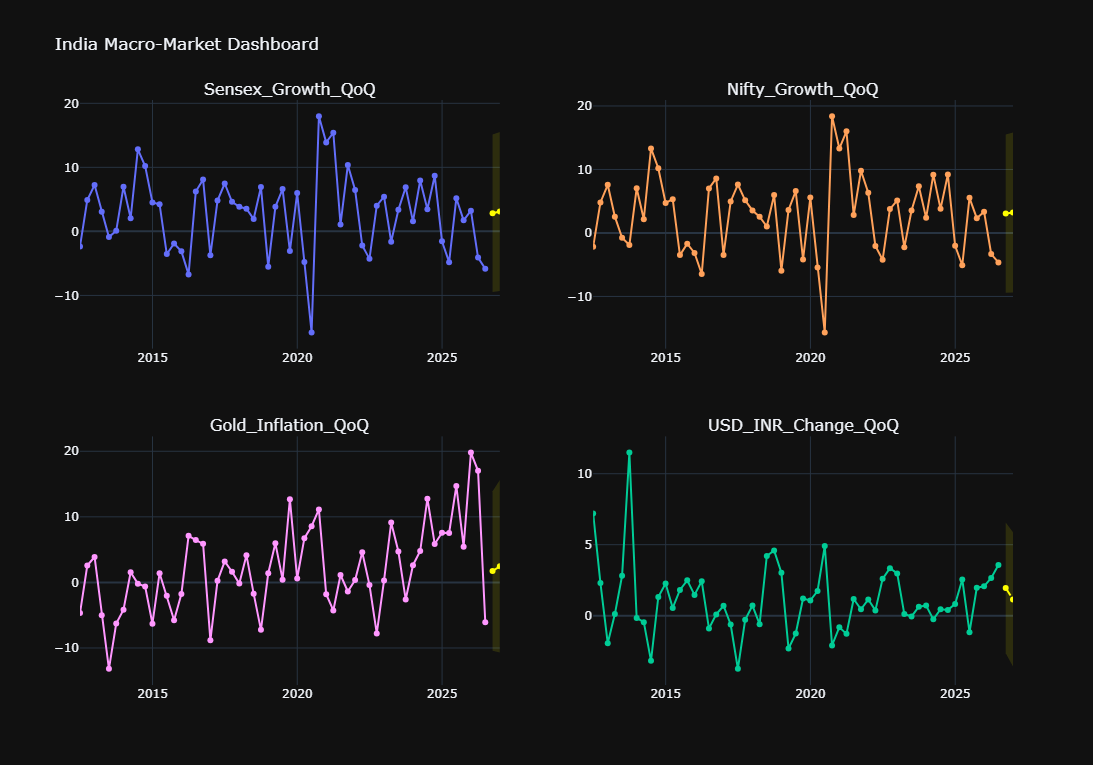

In [36]:
import pandas as pd
import yfinance as yf
import plotly.graph_objects as gr
from plotly.subplots import make_subplots
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
def fetch_macro_data():
    series_dict = {
        "Sensex": "^BSESN",      
        "Nifty": "^NSEI",         
        "Gold": "GC=F",           
        "USD_INR": "INR=X"}
    df_raw = yf.download(list(series_dict.values()), start="2012-01-01", end="2026-06-23")["Close"]
    df_raw = df_raw.rename(columns={v: k for k, v in series_dict.items()})
    return df_raw
def process_data(df_raw):
    df_clean = df_raw.ffill().bfill()
    df_quarterly = df_clean.resample("QE").mean()
    df_stationary = pd.DataFrame(index=df_quarterly.index)
    df_stationary["Sensex_Growth_QoQ"] = df_quarterly["Sensex"].pct_change() * 100
    df_stationary["Nifty_Growth_QoQ"] = df_quarterly["Nifty"].pct_change() * 100
    df_stationary["Gold_Inflation_QoQ"] = df_quarterly["Gold"].pct_change() * 100
    df_stationary["USD_INR_Change_QoQ"] = df_quarterly["USD_INR"].pct_change() * 100
    return df_stationary.dropna()
def run_statistical_tests(df):
    for col in df.columns:
        p_val = adfuller(df[col])[1]
        status = " Stationary" if p_val < 0.05 else " Non-Stationary"
def generate_forecast(df, steps=2):
    model = VAR(df)
    fitted_model = model.fit(maxlags=1) 
    forecast_input = df.values[-fitted_model.k_ar :]
    mid, lower, upper = fitted_model.forecast_interval(forecast_input, steps=steps, alpha=0.05)
    forecast_dates = pd.date_range(start=df.index[-1] + pd.offsets.QuarterEnd(), periods=steps, freq="QE")
    df_forecast = pd.DataFrame(mid, index=forecast_dates, columns=df.columns)
    df_lower = pd.DataFrame(lower, index=forecast_dates, columns=df.columns)
    df_upper = pd.DataFrame(upper, index=forecast_dates, columns=df.columns)
    return df_forecast, df_lower, df_upper
def build_dashboard(df_hist, df_forecast, df_lower, df_upper):
    fig = make_subplots(
        rows=2, cols=2, 
        subplot_titles=list(df_hist.columns),
        vertical_spacing=0.15, horizontal_spacing=0.1 )
    positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
    for idx, col in enumerate(df_hist.columns):
        r, c = positions[idx]
        fig.add_trace(gr.Scatter(x=df_hist.index, y=df_hist[col], mode="lines+markers", name=f"Hist {col}"), row=r, col=c)
        fig.add_trace(gr.Scatter(x=df_forecast.index, y=df_forecast[col], mode="lines+markers", line=dict(dash="dash", color="yellow"), name=f"Fcst {col}"), row=r, col=c)
        fig.add_trace(gr.Scatter(x=df_upper.index, y=df_upper[col], mode="lines", line=dict(width=0), showlegend=False), row=r, col=c)
        fig.add_trace(gr.Scatter(x=df_lower.index, y=df_lower[col], mode="lines", fill="tonexty", fillcolor="rgba(255, 255, 0, 0.12)", line=dict(width=0), name="95% Range"), row=r, col=c)
    fig.update_xaxes(range=[df_hist.index.min(), df_upper.index.max()])
    fig.update_layout(
        title_text="India Macro-Market Dashboard ",
        height=750, width=1100,
        showlegend=False,
        template="plotly_dark")
    fig.show()
if __name__ == "__main__":
    raw_data = fetch_macro_data()
    clean_data = process_data(raw_data)
    run_statistical_tests(clean_data)
    fcst, lower, upper = generate_forecast(clean_data, steps=2)
    build_dashboard(clean_data, fcst, lower, upper)